In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [4]:
file_path = "dataset/circular/26.03.19_09.12.41.008.csv"

df = pd.read_csv(file_path, sep=";")
df.head(50)

,Timestamp(ms),LG-Accel x(g),LG-Accel y(g),LG-Accel z(g),HG-Accel x(g),HG-Accel y(g),HG-Accel z(g),Gyro x(dps),Gyro y(dps),Gyro z(dps)
0,72,0.000000,0.000000,0.000000,0.164944,-0.300608,1.184864,0.000000,0.00000,0.000000
1,75,0.000000,0.000000,0.000000,0.146400,-0.281088,1.221952,0.000000,0.00000,0.000000
2,77,0.000000,0.000000,0.000000,0.164944,-0.222528,1.237568,0.000000,0.00000,0.000000
3,79,0.000000,0.000000,0.000000,0.154208,-0.203008,1.274656,0.000000,0.00000,0.000000
4,81,0.000000,0.000000,0.000000,0.158112,-0.183488,1.270752,0.000000,0.00000,0.000000
5,83,0.000000,0.000000,0.000000,0.175680,-0.169824,1.268800,0.000000,0.00000,0.000000
6,85,0.000000,0.000000,0.000000,0.163968,-0.165920,1.301008,0.000000,0.00000,0.000000
7,87,0.000000,0.000000,0.000000,0.144448,-0.130784,1.312720,0.000000,0.00000,0.000000
8,89,0.032696,-0.024888,1.169492,0.171776,-0.165920,1.308816,0.000000,0.00000,0.000000
9,92,0.000000,0.000000,0.000000,0.156160,-0.154208,1.316624,0.000000,0.00000,0.000000


In [5]:
print(df.shape)
df.columns
df.describe()

(7217, 10)


,Timestamp(ms),LG-Accel x(g),LG-Accel y(g),LG-Accel z(g),HG-Accel x(g),HG-Accel y(g),HG-Accel z(g),Gyro x(dps),Gyro y(dps),Gyro z(dps)
count,7217.000000,7217.000000,7217.000000,7217.000000,7217.000000,7217.000000,7217.000000,7217.000000,7217.000000,7217.000000
mean,7744.511154,0.003368,-0.042088,0.245018,0.133920,-0.300900,1.110544,0.215848,0.023732,-0.114750
std,4430.347794,0.118237,0.125277,0.427951,0.236033,0.205186,0.108559,6.293208,8.208730,15.046535
min,72.000000,-0.522892,-0.592676,0.000000,-0.439200,-0.746640,0.818864,-41.908127,-66.981247,-66.053749
25%,3908.000000,0.000000,0.000000,0.000000,-0.065392,-0.492880,1.021872,0.000000,0.000000,0.000000
50%,7744.000000,0.000000,0.000000,0.000000,0.152256,-0.285968,1.111664,0.000000,0.000000,0.000000
75%,11580.000000,0.000000,0.000000,0.000000,0.334768,-0.114192,1.187792,0.000000,0.000000,0.000000
max,15416.000000,0.524112,0.424316,1.302960,0.661728,0.412848,1.512800,52.591873,55.868752,94.456253


In [6]:
df.columns = [
    "timestamp",
    "LG_x", "LG_y", "LG_z",
    "HG_x", "HG_y", "HG_z",
    "Gyro_x", "Gyro_y", "Gyro_z"
]

In [7]:
invalid_mask = (
    (df["LG_x"] == 0) &
    (df["LG_y"] == 0) &
    (df["LG_z"] == 0) &
    (df["Gyro_x"] == 0) &
    (df["Gyro_y"] == 0) &
    (df["Gyro_z"] == 0)
)

print("Invalid rows:", invalid_mask.sum())

Invalid rows: 5414


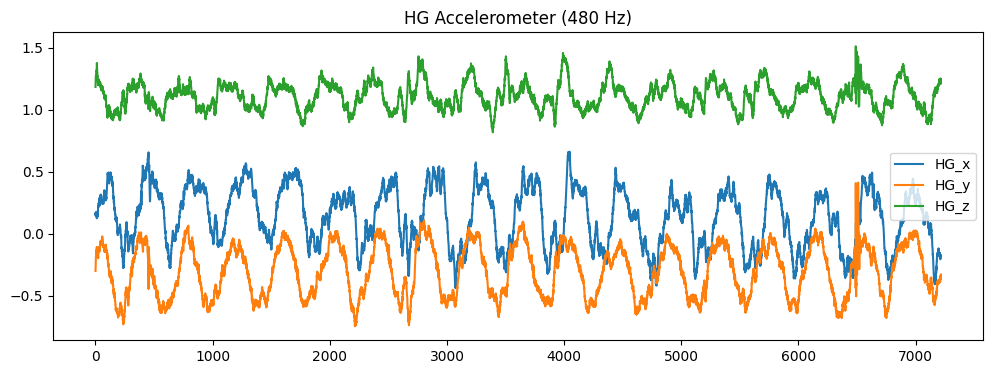

In [8]:
plt.figure(figsize=(12,4))
plt.plot(df["HG_x"], label="HG_x")
plt.plot(df["HG_y"], label="HG_y")
plt.plot(df["HG_z"], label="HG_z")
plt.title("HG Accelerometer (480 Hz)")
plt.legend()
plt.show()

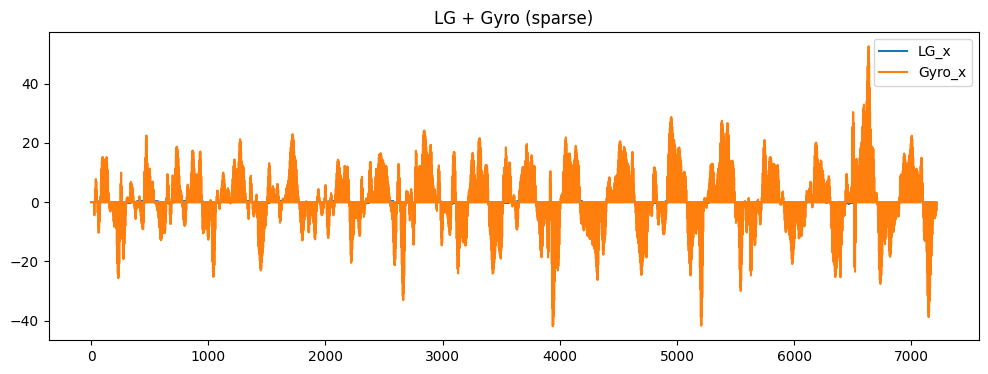

In [9]:
plt.figure(figsize=(12,4))
plt.plot(df["LG_x"], label="LG_x")
plt.plot(df["Gyro_x"], label="Gyro_x")
plt.title("LG + Gyro (sparse)")
plt.legend()
plt.show()

In [10]:
df_hg = df[["timestamp", "HG_x", "HG_y", "HG_z"]]
df_lg = df[~invalid_mask][[
    "timestamp",
    "LG_x", "LG_y", "LG_z",
    "Gyro_x", "Gyro_y", "Gyro_z"
]]

In [11]:
hg_dt = np.diff(df_hg["timestamp"])
print("HG mean dt in ms:", np.mean(hg_dt), "frequency in hz:", 1/(0.001*np.mean(hg_dt)))

HG mean dt in ms: 2.1263858093126387 frequency in hz: 470.281543274244


In [12]:
lg_dt = np.diff(df_lg["timestamp"])
print("LG mean dt in ms:", np.mean(lg_dt), "frequency in hz:", 1/(0.001*np.mean(lg_dt)))

LG mean dt in ms: 8.505549389567147 frequency in hz: 117.57030077640765


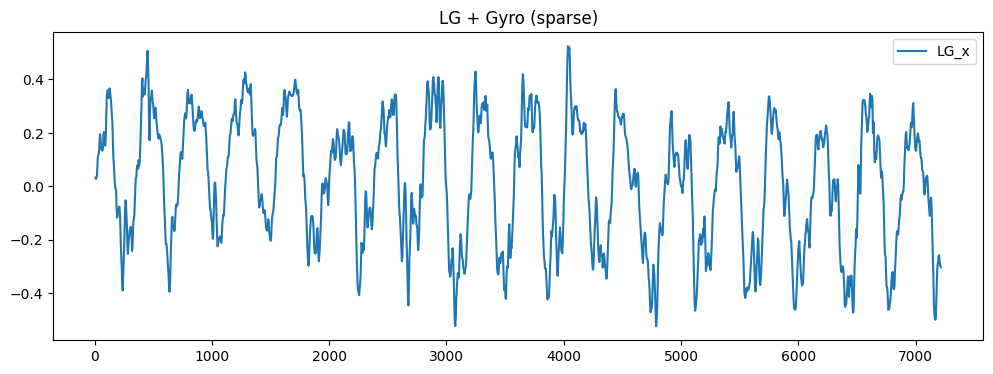

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(df_lg["LG_x"], label="LG_x")
plt.plot(df_lg["Gyro_x"], label="Gyro_x")
plt.title("LG + Gyro (sparse)")
plt.legend()
plt.show()

In [14]:
df_hg_down = df_hg.iloc[::4].reset_index(drop=True)

In [15]:
df_final = pd.merge(df_hg_down, df_lg, on="timestamp", how="inner")

df_final.head(10)

,timestamp,HG_x,HG_y,HG_z,LG_x,LG_y,LG_z,Gyro_x,Gyro_y,Gyro_z
0,89,0.171776,-0.165920,1.308816,0.032696,-0.024888,1.169492,0.000000,0.00000,0.000000
1,98,0.160064,-0.122976,1.378112,0.028060,0.008052,1.199992,0.000000,0.00000,0.000000
2,107,0.156160,-0.130784,1.276608,0.032696,0.008784,1.180716,0.000000,0.00000,0.000000
3,115,0.163968,-0.169824,1.223904,0.038064,-0.020496,1.127280,0.000000,0.00000,0.000000
4,124,0.222528,-0.173728,1.223904,0.075884,-0.045872,1.078968,0.000000,0.00000,0.000000
5,132,0.226432,-0.150304,1.227808,0.110288,-0.023180,1.094828,-4.458125,-1.88125,23.126249
6,141,0.230336,-0.119072,1.223904,0.116388,0.006344,1.092876,-0.048125,0.91875,21.936249
7,149,0.253760,-0.099552,1.216096,0.124196,0.013908,1.078236,4.571875,1.26875,20.886250
8,158,0.277184,-0.080032,1.223904,0.143228,0.038552,1.082628,7.791875,0.77875,20.746250
9,166,0.316224,-0.068320,1.203408,0.176900,0.063196,1.069696,7.021875,3.29875,20.326250


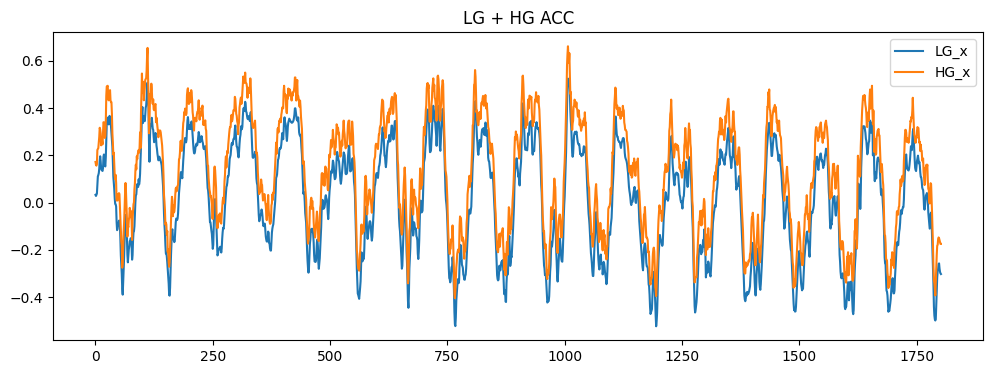

In [19]:
plt.figure(figsize=(12,4))
plt.plot(df_final["LG_x"], label="LG_x")
plt.plot(df_final["HG_x"], label="HG_x")
plt.title("LG + HG ACC")
plt.legend()
plt.show()

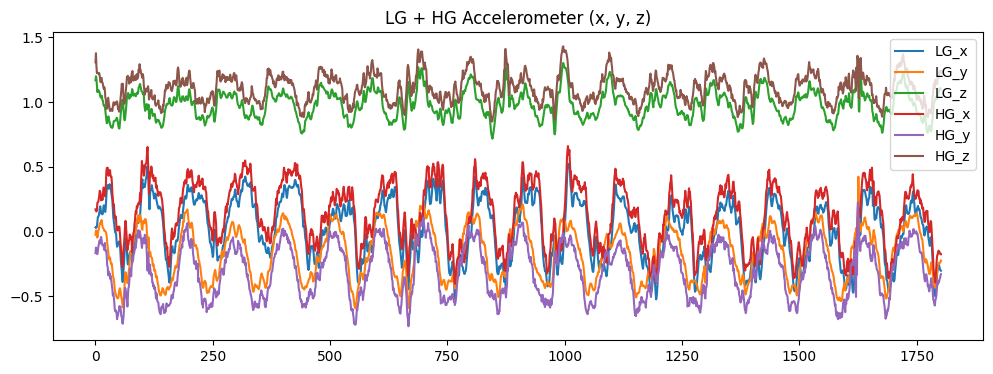

In [20]:
plt.figure(figsize=(12,4))

# LG accel
plt.plot(df_final["LG_x"], label="LG_x")
plt.plot(df_final["LG_y"], label="LG_y")
plt.plot(df_final["LG_z"], label="LG_z")

# HG accel
plt.plot(df_final["HG_x"], label="HG_x")
plt.plot(df_final["HG_y"], label="HG_y")
plt.plot(df_final["HG_z"], label="HG_z")

plt.title("LG + HG Accelerometer (x, y, z)")
plt.legend()
plt.show()

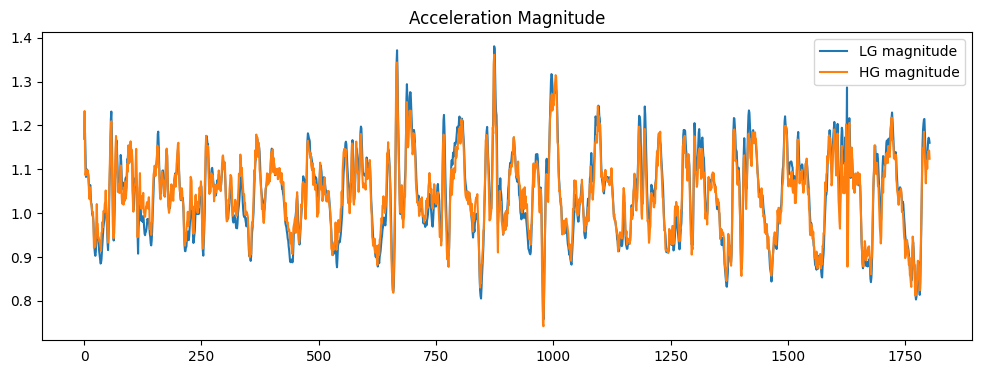

: 

In [ ]:
df_final["LG_mag"] = np.sqrt(df_final["LG_x"]**2 + df_final["LG_y"]**2 + df_final["LG_z"]**2)
df_final["HG_mag"] = np.sqrt(df_final["HG_x"]**2 + df_final["HG_y"]**2 + df_final["HG_z"]**2)

plt.figure(figsize=(12,4))
plt.plot(df_final["LG_mag"], label="LG magnitude")
plt.plot(df_final["HG_mag"]-0.16, label="HG magnitude")
plt.title("Acceleration Magnitude")
plt.legend()
plt.show()